Kacper Kaszuba

mozna pomalowć kropki (node) roznymi kolorami w zalezności od intensywności

lub mozna pomalować linie w zalezności od intensywności


# Lab. Metro w Paryżu

* Krzysztof Molenda, 2025-05-15

Ćwiczenie do samodzielnego wykonania, ze wspomaganiem asystenta AI

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import scipy
import math

## Analiza danych źródłowych

W załączonych w katalogu projektu plikach `.csv` zamieszczone zostały dane dotyczące fragmentu sieci metra w Paryżu.

Wczytaj je. Zapoznaj się z tymi danymi.

In [ ]:
# Wczytaj dane, wyświetl
liaisons = pd.read_csv('liaisons.csv')
liaisons.head(5)

,start,stop,ligne
0,LADEFENSE,ESPLANADEDELADEFENSE,1
1,ESPLANADEDELADEFENSE,PONTDENEUILLY,1
2,PONTDENEUILLY,LESSABLONS,1
3,LESSABLONS,PORTEMAILLOT,1
4,PORTEMAILLOT,ARGENTINE,1


In [ ]:
stations = pd.read_csv('stations.csv')
stations.head(5)

,nom_clean,nom_gare,x,y,Trafic,Ville,ligne
0,ABBESSES,Abbesses,651449.5655,6.865157e+06,2450498,Paris,12
1,ALESIA,Alésia,650605.2307,6.858892e+06,5113245,Paris,4
2,ALEXANDREDUMAS,Alexandre Dumas,655576.9894,6.861986e+06,3668682,Paris,2
3,ALMAMARCEAU,Alma-Marceau,648719.8026,6.862975e+06,4561735,Paris,9
4,ANATOLEFRANCE,Anatole France,647574.9141,6.866023e+06,3734650,Levallois-Perret,3


## Utworzenie grafu

Utwórz graf połączeń między stacjami (wielokrawędziowy - bo stacje mogą być połączone wieloma liniami)

In [ ]:
# Utwórz graf wielokrawędziowy
G = nx.MultiDiGraph()

for _, row in stations.iterrows():
  G.add_node(row['nom_clean'],
            nom_gare=row['nom_gare'],
            x=row['x'],
            y=row['y'],
            Trafic = row['Trafic'],
            Ville = row['Ville'],
            ligne = row['ligne']
             )


for _, row in liaisons.iterrows():
  G.add_edge(row['start'],
              row['stop'],
             ligne=row['ligne'])


## Rysowanie grafu

Narysuj ten graf (jakkolwiek)

/tmp/ipykernel_1074/3750366409.py:9: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  edge_colors_mapped = pd.factorize(line_labels)[0]


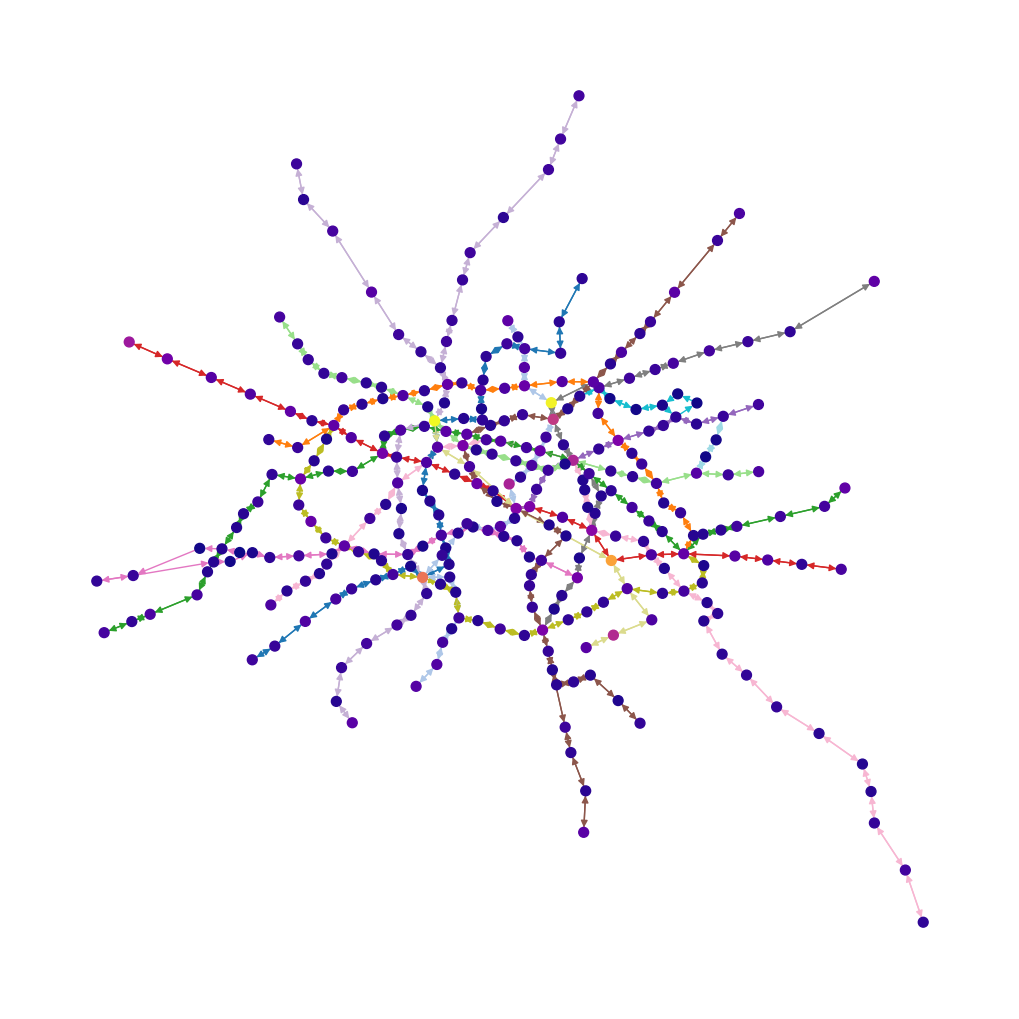

In [ ]:
# Upiększanie grafu
pos = {node: (data['x'], data['y']) for node, data in G.nodes(data=True)}

# Kolorwanie node ze względu na Trafic
traffic_values = [G.nodes[node]['Trafic'] for node in G.nodes()]

# Kolrowanie krawędzi ze względu na nr Linii
line_labels = [data['ligne'] for u, v, data in G.edges(data=True)]
edge_colors_mapped = pd.factorize(line_labels)[0]

plt.figure(figsize=(10,10))
nx.draw(G,
        pos=pos,
        node_size=50,
        node_color=traffic_values,
        # cmap=plt.cm.YlOrRd,
        cmap='plasma',
        with_labels=False,
        edge_color=edge_colors_mapped,
        edge_cmap=plt.cm.tab20,
        width=1)

Spróbuj ustalić parametry i narysować go jak na załączonym pliku (wspomaganie AI, dokumentacja NetworkX)

> współrzędne geograficzne stacji są informacją o lokalizacji węzłów na rysunku grafu w `matplotlib`

## Graf na mapie

Chcemy uzyć biblioteki `Folium`. Współrzędne stacji podane są w lokalnym układzie francuskim - musimy przeliczyć je na na szerokość i długość geograficzną (lat/lon w WGS84).

Zrobić to można przy uzyciu biblioteki `pyproj`

In [ ]:
from pyproj import Transformer

# Utwórz transformator: z EPSG:2154 (Lambert-93) do EPSG:4326 (WGS84)
transformer = Transformer.from_crs("EPSG:2154", " EPSG:4326", always_xy=True)

# Przelicz współrzędne
for attr, data in G.nodes(data=True):
  lon, lat = transformer.transform(G.nodes[attr]['x'], G.nodes[attr]['y'])
  G.nodes[attr]['lat'] = lat
  G.nodes[attr]['lon'] = lon

In [ ]:
lat, lon

(48.883809201247004, 2.304674440528409)

In [ ]:
%pip install folium
import folium

In [ ]:
from math import sqrt
# Utwórz mapę w centrum Paryża
m = folium.Map(location=[lat, lon], zoom_start=12)

# notka: Najpierw dodam linie a potem Przystanki aby linie nie "przykrywały" przystanków
# Tak jest bardziej przejrzyście

# Dodaj linie jako polylines

unique_lines = sorted(list(set(data['ligne']  for u, v, data in G.edges(data=True))))
cmap= plt.get_cmap('tab20', len(unique_lines))
line_colors = {line: plt.cm.colors.to_hex(cmap(i)) for i, line, in enumerate(unique_lines)}

for u, v, data in G.edges(data=True):
  if 'lat' in G.nodes[u] and 'lat' in G.nodes[v]:
    A = G.nodes[u]['lat'], G.nodes[u]['lon']
    B = G.nodes[v]['lat'], G.nodes[v]['lon']
    coordinates = [A, B]

    current_color = line_colors.get(data['ligne'], 'gray')

    folium.PolyLine(locations=coordinates,
                    # Dodamy kolor zaleznosci od lini
                    color=current_color,
                    weight=4,
                    oppacity=0.8,
                    tooltip=f"Linia: {data['ligne']}"
                    ).add_to(m)

# Dodaj stacje jako punkty



for attr, data in G.nodes(data=True):
  latM = G.nodes[attr]['lat']
  lonM = G.nodes[attr]['lon']

  v_radius = 2 +  sqrt(G.nodes[attr]['Trafic']) / 600
  if G.nodes[attr]['Trafic'] < 2000000:
    v_color = 'Green'
  elif G.nodes[attr]['Trafic'] in range (2000000, 10000000):
    v_color = 'Orange'
  elif G.nodes[attr]['Trafic'] > 10000000:
    v_color = 'Red'
  else:
    v_color = 'Black'

  folium.CircleMarker(location=[latM, lonM],
                      radius=v_radius,
                      # Tu mozemy dać w zaleznosic od Trafic
                      color='black',
                      weight=1.7,
                      fill_opacity=0.9,
                      opacity=1,
                      fill_color=v_color,
                      tooltip=G.nodes[attr]['nom_gare']
                      ).add_to(m)




# Zapisz mapę do pliku HTML
m.save('paris_metro_map_Kaszuba.html')

# wyświetl mapę
m

## Pytania do grafu

### Statystyki opisowe

* liczba stacji
* liczba połączeń
* liczba linii
* stopnie węzłów: minimalny, średni, maksymalny stopień
* top 5 stacji pod względem liczby połączeń
* największe stacje pod względem ruchu pasażerskiego (`Trafic`)
* liczba stacji przesiadkowych

In [ ]:
import pprint

print(f"Liczba stacji wynosi: {G.number_of_nodes()}")
print(f"Liczba połączeń wynosi: {G.number_of_edges()}")
print(f"Liczba linii wynosi: {len(unique_lines)}")
print()

stopnie = dict(G.degree())
print(f"Stopnie węzłów:\n\t- Minimalny: {min(stopnie.values())}\n\t- Maksymalny: {max(stopnie.values())}\n\t- Sredni: {sum(stopnie.values())/G.number_of_nodes():.3f}")
print()

top5_polaczen = sorted(stopnie.items(), key=lambda x: x[1], reverse=True)[:5]
print(f"Top 5 staji pod względem połączeń:")
for stacja, liczba in top5_polaczen:
  nazwa = G.nodes[stacja]['nom_gare']
  print(f"\t- {nazwa}: {liczba} połączeń")
print()

top5_trafic= sorted(G.nodes(data=True), key=lambda x: x[1].get('Trafic', 0), reverse=True)[:5]
print("Top 5 stacji pod względem ruchu:")
for stacja, dane in top5_trafic:
  print(f"\t- {dane['nom_gare']}: {dane['Trafic']:,} osób")
print()

stacje_przesiadki = [stacja for stacja, stopien in stopnie.items() if stopien > 4]
print(f"Liczba stacji przesiadkowych wynosi: {len(stacje_przesiadki)}")

Liczba stacji wynosi: 302
Liczba połączeń wynosi: 726
Liczba linii wynosi: 16

Stopnie węzłów:
	- Minimalny: 2
	- Maksymalny: 20
	- Sredni: 4.808

Top 5 staji pod względem połączeń:
	- République: 20 połączeń
	- Châtelet: 18 połączeń
	- Montparnasse-Bienvenüe: 16 połączeń
	- Saint-Lazare: 14 połączeń
	- Bastille: 12 połączeń

Top 5 stacji pod względem ruchu:
	- Saint-Lazare: 46,679,970 osób
	- Gare du Nord: 45,793,828 osób
	- Gare de Lyon: 36,864,326 osób
	- Montparnasse-Bienvenüe: 30,646,580 osób
	- Gare de l'Est: 21,432,041 osób

Liczba stacji przesiadkowych wynosi: 60


### Analiza centralności

* Średnica grafu (maksymalna liczba przesiadek potrzebnych do przejazdu między dwiema stacjami)
* Promień grafu (najmniejsza maksymalna odległość od najbardziej centralnej stacji)
* Średnia długość wszystkich najkrótszych ścieżek (przeciętna liczba przesiadek w podróży)
* Gęstosć grafu

In [ ]:
G_undirected= G.to_undirected()
if nx.is_connected(G_undirected):
  print(f"Średnica grafu wynosi: {nx.diameter(G_undirected)}")
  print(f"Promień grafu wynosi: {nx.radius(G_undirected)}")
  print(f"Średnia długość wszystkich najkrótszych ścieżek wynosi: {nx.average_shortest_path_length(G_undirected)}")

print(f"Gęstość grafu wynosi: {nx.density(G)}")


Średnica grafu wynosi: 34
Promień grafu wynosi: 17
Średnia długość wszystkich najkrótszych ścieżek wynosi: 11.960528921255857
Gęstość grafu wynosi: 0.007986622956590615


In [ ]:
# PageRank - Stacje wpływowe przez połączenia z innymi ważnymi stacjami, Top 5
paris_pagerank = nx.pagerank(G)

sortowene = sorted(paris_pagerank.items(), key=lambda x: x[1], reverse=True)[:5]
print("Najbardziej wpływowe stacje:")
for stacja, liczba in sortowene:
  nazwa = G.nodes[stacja]['nom_gare']
  print(f"\t- {nazwa}: {liczba:.4f}")


Najbardziej wpływowe stacje:
	- République: 0.0097
	- Montparnasse-Bienvenüe: 0.0091
	- Châtelet: 0.0089
	- La Motte Picquet-Grenelle: 0.0076
	- Nation: 0.0075


:::{seealso} Degree Centrality
:class: dropdown
**Degree Centrality** (_centralność stopnia_)
: to podstawowa miara w analizie sieci, która określa liczbę bezpośrednich połączeń danego węzła (stacji metra) z innymi węzłami. W kontekście metra paryskiego mierzy, ile linii lub połączeń przechodzi przez daną stację. Im wyższa wartość, tym większe znaczenie stacji jako węzła przesiadkowego.

*  Stacje o wysokim stopniu skracają czas podróży, minimalizując liczbę przesiadek.
*  Zamknięcie stacji z wysokim degree_centrality sparaliżuje znaczną część sieci.
*  Te stacje mają zwykle najwyższy ruch
:::

In [ ]:
# 1. Degree Centrality (liczba połączeń)
degree_c = sorted(nx.degree_centrality(G).items(), key=lambda x: x[1], reverse=True)[:5]

print(f"Stacje z największą ilością połączeń to:")
for stacja, liczba in degree_c:
  nazwa = G.nodes[stacja]['nom_gare']
  print(f"\t- {nazwa}: {liczba:.4f}")

Stacje z największą ilością połączeń to:
	- République: 0.0664
	- Châtelet: 0.0598
	- Montparnasse-Bienvenüe: 0.0532
	- Saint-Lazare: 0.0465
	- Bastille: 0.0399


:::{seealso} Betweenness Centrality
:class: dropdown
**Betweenness Centrality** (_centralność pośrednictwa_)
:  to miara centralności oparta na najkrótszych ścieżkach w grafie. Mierzy, jak często dany węzeł (stacja) leży na najkrótszych trasach pomiędzy wszystkimi parami innych stacji w sieci.

* Miara ta koncentruje się nie na lokalizacji stacji jako punktu docelowego, ale na jej roli jako węzła przesiadkowego. Stacja może być mocno używana niekoniecznie dlatego, że znajduje się przy atrakcyjnym miejscu, ale dlatego, że służy jako punkt przesiadkowy do wielu innych lokalizacji
* Stacje o wysokiej centralności pośrednictwa mają znaczny wpływ na sieć metra, ponieważ kontrolują przepływ pasażerów między innymi stacjami
* Usunięcie stacji o wysokiej betweenness centrality (np. z powodu awarii) najbardziej zakłóci funkcjonowanie całego systemu metra
:::

In [ ]:
# 2. Betweenness Centrality (pośrednictwo w ścieżkach)
betweenness_c = sorted(nx.betweenness_centrality(G).items(), key=lambda x: x[1], reverse=True)[:5]
print(f"Stacje z największym pośrednictwem w ścieżkach to:")
for stacja, liczba in betweenness_c:
  nazwa = G.nodes[stacja]['nom_gare']
  print(f"\t- {nazwa}: {liczba:.4f}")

Stacje z największym pośrednictwem w ścieżkach to:
	- Châtelet: 0.3343
	- Madeleine: 0.3065
	- Gare de Lyon: 0.2647
	- Concorde: 0.2254
	- Pyramides: 0.2225


:::{seealso} Closeness Centrality
:class: dropdown
**Closeness centrality** (_centralność bliskości_)
: to miara w analizie sieci, która określa, jak "blisko" dany węzeł znajduje się względem wszystkich pozostałych węzłów w sieci. Węzły o wysokiej centralności bliskości mogą szybko dotrzeć do wszystkich innych węzłów, co czyni je strategicznymi punktami przepływu informacji lub ruchu.

closeness centrality mierzy
* jak łatwo ze stacji można dotrzeć do wszystkich innych stacji (z minimalną liczbą przesiadek)
* efektywność stacji jako punktu startowego podróży w całej sieci
:::

In [ ]:
# 3. Closeness Centrality (bliskość do innych)
closeness_c = sorted(nx.closeness_centrality(G).items(), key=lambda x: x[1], reverse=True)[:5]
print(f"Stacje które są najbliżej innych to:")
for stacja, liczba in closeness_c:
  nazwa = G.nodes[stacja]['nom_gare']
  print(f"\t- {nazwa}: {liczba:.4f}")

Stacje które są najbliżej innych to:
	- Châtelet: 0.1310
	- Madeleine: 0.1307
	- Pyramides: 0.1298
	- Opéra: 0.1270
	- Concorde: 0.1247


In [ ]:
# Połączenie wyników z danymi o ruchu
trafic_dict = {node: data['Trafic'] for node, data in G.nodes(data=True)}
df_stats = pd.DataFrame({'Trafic': trafic_dict,
                         'PageRank': paris_pagerank,
                         'Degree Centrality': nx.degree_centrality(G),
                         'Betweenness Centrality':nx.betweenness_centrality(G),
                         'Closeness Centrality':nx.closeness_centrality(G)})

# korelacje = pd.Series([top5_trafic, sortowene, degree_c, betweenness_c, closeness_c])
df_stats

,Trafic,PageRank,Degree Centrality,Betweenness Centrality,Closeness Centrality
ABBESSES,2450498,0.002822,0.013289,0.018714,0.090472
ALESIA,5113245,0.003283,0.013289,0.013245,0.071412
ALEXANDREDUMAS,3668682,0.002885,0.013289,0.037436,0.095223
ALMAMARCEAU,4561735,0.002646,0.013289,0.042294,0.099176
ANATOLEFRANCE,3734650,0.003803,0.013289,0.006645,0.065492
...,...,...,...,...,...
VILLEJUIFPAULVAILLANTCOUTURIER,2470026,0.003735,0.013289,0.006645,0.063235
VILLIERS,6237308,0.005032,0.026578,0.074902,0.106061
VOLONTAIRES,2342480,0.002861,0.013289,0.032780,0.082647
VOLTAIRE,5195333,0.002835,0.013289,0.010216,0.090964


In [ ]:
df_stats.corr()

,Trafic,PageRank,Degree Centrality,Betweenness Centrality,Closeness Centrality
Trafic,1.000000,0.469845,0.516797,0.451675,0.199217
PageRank,0.469845,1.000000,0.915141,0.620827,0.186211
Degree Centrality,0.516797,0.915141,1.000000,0.733455,0.492130
Betweenness Centrality,0.451675,0.620827,0.733455,1.000000,0.523743
Closeness Centrality,0.199217,0.186211,0.492130,0.523743,1.000000


In [ ]:
# Najważniejsze stacje według wszystkich metryk


df_stats_rank = df_stats.rank(ascending=False)
av_stat = df_stats_rank.mean(axis=1)
df_stats['av_stat'] = av_stat
display(df_stats.sort_values('av_stat').head(10))

,Trafic,PageRank,Degree Centrality,Betweenness Centrality,Closeness Centrality,av_stat
CHATELET,12505675,0.008940,0.059801,0.334294,0.131040,3.6
STLAZARE,46679970,0.006759,0.046512,0.190953,0.123108,4.8
OPERA,11175606,0.005448,0.039867,0.096910,0.126951,13.3
REPUBLIQUE,18327920,0.009669,0.066445,0.163190,0.107308,13.4
BASTILLE,13172392,0.006715,0.039867,0.089558,0.117440,14.5
MADELEINE,7088856,0.005341,0.039867,0.306524,0.130699,15.1
GAREDELYON,36864326,0.004352,0.026578,0.264669,0.124124,17.4
CONCORDE,6325918,0.005770,0.039867,0.225399,0.124741,17.7
NATION,8638165,0.007505,0.039867,0.121669,0.107270,21.3
GAREDELEST,21432041,0.006079,0.039867,0.106770,0.101792,23.5


### Spójnosć, mosty i punkty artykulacji

In [ ]:
# Czy graf jest spójny?
print(f"Graf jest spójny: {nx.is_connected(G_undirected)}")

# Liczba komponentów spójnych
print(f"Liczba komponentów spójnych wynosi: {nx.number_connected_components(G_undirected)}")

# Lista komponentów spójnych
komponenty_spojne = nx.connected_components(G_undirected)
for i, komponent in enumerate(komponenty_spojne, 1):
    print(f"Komponent {i} (liczba stacji: {len(komponent)}):")
    nazwy_stacji = [G.nodes[stacja].get('nom_gare', stacja) for stacja in komponent]
    print(f"  {', '.join(nazwy_stacji[:10])}{'...' if len(nazwy_stacji) > 10 else ''}\n")

# Spójność krawędziowa i wierzchołkowa
print(f"Spójność wierzchołkowa: {nx.node_connectivity(G_undirected)}")
print(f"Spójność krawędziowa: {nx.edge_connectivity(G_undirected)}")


Graf jest spójny: True
Liczba komponentów spójnych wynosi: 1
Komponent 1 (liczba stacji: 302):
  Oberkampf, Porte de Saint-Ouen, Nation, Malakoff-Plateau de Vanves, Église de Pantin, Esplanade de la Défense, Saint-Placide, Ledru Rollin, Saint-Augustin, Porte Dauphine...

Spójność wierzchołkowa: 1
Spójność krawędziowa: 1


In [ ]:
# Lista wszystkich mostów w grafie
lista_mostow  = list(nx.bridges(G_undirected))
ilosc_mostow = len(lista_mostow)
print(f"Ilość mostów w grafie wynosi: {ilosc_mostow}")
print("Oto lista wszystkich mostów w Grafie:\n")
display(lista_mostow)


Ilość mostów w grafie wynosi: 116
Oto lista wszystkich mostów w Grafie:



[('ALESIA', 'PORTEDORLEANS'),
 ('ALESIA', 'MOUTONDUVERNET'),
 ('ANATOLEFRANCE', 'LOUISEMICHEL'),
 ('ANATOLEFRANCE', 'PONTDELEVALLOISBECON'),
 ('ARGENTINE', 'CHARLESDEGAULLEETOILE'),
 ('ARGENTINE', 'PORTEMAILLOT'),
 ('ASNIERESGENNEVILLIERSLESCOURTILLES', 'LESAGNETTES'),
 ('AUBERVILLIERSPANTINQUATRECHEMINS', 'PORTEDELAVILLETTE'),
 ('AUBERVILLIERSPANTINQUATRECHEMINS', 'FORTDAUBERVILLIERS'),
 ('BALARD', 'LOURMEL'),
 ('BASILIQUEDESTDENIS', 'STDENISPORTEDEPARIS'),
 ('BASILIQUEDESTDENIS', 'STDENISUNIVERSITE'),
 ('BERAULT', 'CHATEAUDEVINCENNES'),
 ('BERAULT', 'STMANDE'),
 ('BERCY', 'COURSTEMILION'),
 ('BIBLIOTHEQUEFRANCOISMITTERRAND', 'OLYMPIADES'),
 ('BIBLIOTHEQUEFRANCOISMITTERRAND', 'COURSTEMILION'),
 ('BILLANCOURT', 'MARCELSEMBAT'),
 ('BILLANCOURT', 'PONTDESEVRES'),
 ('BOBIGNYPABLOPICASSO', 'BOBIGNYPANTINRAYMONDQUENEAU'),
 ('BOBIGNYPANTINRAYMONDQUENEAU', 'EGLISEDEPANTIN'),
 ('BOUCICAUT', 'FELIXFAURE'),
 ('BOUCICAUT', 'LOURMEL'),
 ('BOULOGNEJEANJAURES', 'BOULOGNEPONTDESTCLOUD'),
 ('BROCHANT'

In [ ]:
# Lista punktów artykulacji
lista_p_artykulacji  = list(nx.articulation_points(G_undirected))
ilosc_p_artykulacji = len(lista_p_artykulacji)
print(f"Ilość mostów w grafie wynosi: {ilosc_p_artykulacji}")
print("Oto lista wszystkich mostów w Grafie:\n")
display(lista_p_artykulacji)


Ilość mostów w grafie wynosi: 111
Oto lista wszystkich mostów w Grafie:



['ANATOLEFRANCE',
 'LOUISEMICHEL',
 'PORTEDECHAMPERRET',
 'PEREIRE',
 'WAGRAM',
 'MALESHERBES',
 'VILLIERS',
 'ESPLANADEDELADEFENSE',
 'PONTDENEUILLY',
 'LESSABLONS',
 'PORTEMAILLOT',
 'ARGENTINE',
 'CHARLESDEGAULLEETOILE',
 'BOULOGNEJEANJAURES',
 'BILLANCOURT',
 'MARCELSEMBAT',
 'PORTEDESTCLOUD',
 'EXELMANS',
 'MICHELANGEMOLITOR',
 'PORTEDORLEANS',
 'ALESIA',
 'MOUTONDUVERNET',
 'DENFERTROCHEREAU',
 'PORTEDEBAGNOLET',
 'GAMBETTA',
 'PORTEDESLILAS',
 'BOBIGNYPANTINRAYMONDQUENEAU',
 'EGLISEDEPANTIN',
 'HOCHE',
 'PORTEDEPANTIN',
 'OURCQ',
 'LAUMIERE',
 'JAURES',
 'CROIXDECHAVAUX',
 'ROBESPIERRE',
 'PORTEDEMONTREUIL',
 'MARAICHERS',
 'BUZENVAL',
 'NATION',
 'BERAULT',
 'STMANDE',
 'PORTEDEVINCENNES',
 'CRETEILPREFECTURE',
 'CRETEILUNIVERSITE',
 'CRETEILLECHAT',
 'MAISONSALFORTLESJUILLIOTTES',
 'MAISONSALFORTSTADE',
 'ECOLEVETERINAIREDEMAISONSALFORT',
 'CHARENTONECOLES',
 'LIBERTE',
 'PORTEDECHARENTON',
 'PORTEDOREE',
 'MICHELBIZOT',
 'DAUMESNIL',
 'BIBLIOTHEQUEFRANCOISMITTERRAND',
 'COURS

### Nakrótsza ścieżka między stacją `A` a stacją `B`

In [ ]:
# Funkcja wypisująca najkrótszą ścieżkę między dwiema stacjami
def shortest_pathP(G, st_A, st_B):
  path = nx.shortest_path(G, source=st_A, target=st_B)

  # wypisanie lini po których sie porsuzamy
  print("Detailed guide:")
  lines = set()
  old_line = None
  for p in range(len(path) - 1):
    line_a = G.get_edge_data(path[p], path[p+1])
    if old_line != line_a[0]['ligne']:
      if old_line is not None:
        print(f"\tChange line!! from {old_line} to {line_a[0]['ligne']}")
      old_line = line_a[0]['ligne']
    lines.add(line_a[0]['ligne'])

    print(f"{path[p]}, -> {path[p+1]} (Line {line_a[0]['ligne']})")

  print(f"\nSummary:\n\t- Shortest path between {st_A} and {st_B} is:\n\t  {path}\n\t- Lines to use: {lines}")

print("--Example 1:--")
shortest_pathP(G_undirected, 'ABBESSES', 'VILLIERS')

print("\n--Example 2:--")
shortest_pathP(G_undirected, 'ESPLANADEDELADEFENSE', 'JOURDAIN')

print("\n--Example 2:--")
shortest_pathP(G_undirected, 'LACOURNEUVEMAI', 'PORTEDEBAGNOLET')

--Example 1:--
Detailed guide:
ABBESSES, -> PIGALLE (Line 12)
	Change line!! from 12 to 2
PIGALLE, -> BLANCHE (Line 2)
BLANCHE, -> PLACEDECLICHY (Line 2)
PLACEDECLICHY, -> ROME (Line 2)
ROME, -> VILLIERS (Line 2)

Summary:
	- Shortest path between ABBESSES and VILLIERS is:
	  ['ABBESSES', 'PIGALLE', 'BLANCHE', 'PLACEDECLICHY', 'ROME', 'VILLIERS']
	- Lines to use: {'12', '2'}

--Example 2:--
Detailed guide:
ESPLANADEDELADEFENSE, -> PONTDENEUILLY (Line 1)
PONTDENEUILLY, -> LESSABLONS (Line 1)
LESSABLONS, -> PORTEMAILLOT (Line 1)
PORTEMAILLOT, -> ARGENTINE (Line 1)
ARGENTINE, -> CHARLESDEGAULLEETOILE (Line 1)
CHARLESDEGAULLEETOILE, -> GEORGEV (Line 1)
GEORGEV, -> FRANKLINDROOSEVELT (Line 1)
FRANKLINDROOSEVELT, -> CHAMPSELYSEESCLEMENCEAU (Line 1)
CHAMPSELYSEESCLEMENCEAU, -> CONCORDE (Line 1)
	Change line!! from 1 to 8
CONCORDE, -> MADELEINE (Line 8)
	Change line!! from 8 to 14
MADELEINE, -> PYRAMIDES (Line 14)
PYRAMIDES, -> CHATELET (Line 14)
	Change line!! from 14 to 1
CHATELET, -> HOTELD

### Linie
* Napisz funkcję zwracającą listę stacji dla wskazanej linii. Przetestuj
* Wypisz wszystkie linie, podając stację początkową, posrednie i końcową
* Stacje końcowe na poszczególnych liniach

In [ ]:
def stations_of_line(G, line):
  # Zwraca stacje dla danej linii
  stations = set()
  for u, v, at in G.edges(data=True):
    if at['ligne'] == str(line):
      stations.update([u, v])
  return stations


stations_line = stations_of_line(G_undirected, 5)
stations_line

{'BASTILLE',
 'BOBIGNYPABLOPICASSO',
 'BOBIGNYPANTINRAYMONDQUENEAU',
 'BREGUETSABIN',
 'CAMPOFORMIO',
 'EGLISEDEPANTIN',
 'GAREDAUSTERLITZ',
 'GAREDELEST',
 'GAREDUNORD',
 'HOCHE',
 'JACQUESBONSERGENT',
 'JAURES',
 'LAUMIERE',
 'OBERKAMPF',
 'OURCQ',
 'PLACEDITALIE',
 'PORTEDEPANTIN',
 'QUAIDELARAPEE',
 'REPUBLIQUE',
 'RICHARDLENOIR',
 'STALINGRAD',
 'STMARCEL'}

In [ ]:
def summarize_line(G):
  # Wpisuje linie dla danej trasy
  all_lines = set()

  for u, v, at in G.edges(data=True):
    all_lines.add(at['ligne'])

  for linia in  all_lines:
    stacje_linii = set()
    edges_of_line = []
    for u, v, key, at in G.edges(data=True, keys=True):
      if at['ligne'] == linia:
        stacje_linii.update([u,v])
        edges_of_line.append((u, v, key))

    subgraph = G.edge_subgraph(edges_of_line)

    stacje_krancowe = set()
    for stacja, stopien in subgraph.degree():
      if stopien == 1:
        stacje_krancowe.add(stacja)

    stacje_posrednie = stacje_linii - stacje_krancowe

    print(f"Linia {linia}:\n  Krańce: {stacje_krancowe}\n  Pośrednie: {stacje_posrednie}\n")


summarize_line(G_undirected)




Linia 5:
  Krańce: {'PLACEDITALIE', 'BOBIGNYPABLOPICASSO'}
  Pośrednie: {'OURCQ', 'OBERKAMPF', 'LAUMIERE', 'EGLISEDEPANTIN', 'CAMPOFORMIO', 'GAREDAUSTERLITZ', 'RICHARDLENOIR', 'BREGUETSABIN', 'JAURES', 'PORTEDEPANTIN', 'STMARCEL', 'HOCHE', 'REPUBLIQUE', 'QUAIDELARAPEE', 'BOBIGNYPANTINRAYMONDQUENEAU', 'GAREDUNORD', 'STALINGRAD', 'JACQUESBONSERGENT', 'GAREDELEST', 'BASTILLE'}

Linia 7bis:
  Krańce: {'LOUISBLANC'}
  Pośrednie: {'BOTZARIS', 'PRESTGERVAIS', 'BUTTESCHAUMONT', 'PLACEDESFETES', 'JAURES', 'BOLIVAR', 'DANUBE'}

Linia 12:
  Krańce: {'FRONTPOPULAIRE', 'MAIRIEDISSY'}
  Pośrednie: {'JULESJOFFRIN', 'MADELEINE', 'STLAZARE', 'PASTEUR', 'CONVENTION', 'SOLFERINO', 'MONTPARNASSEBIENVENUE', 'SEVRESBABYLONE', 'CONCORDE', 'VAUGIRARD', 'PORTEDEVERSAILLES', 'PIGALLE', 'CORENTINCELTON', 'ABBESSES', 'PORTEDELACHAPELLE', 'VOLONTAIRES', 'TRINITEDESTIENNEDORVES', 'MARXDORMOY', 'STGEORGES', 'RUEDUBAC', 'RENNES', 'FALGUIERE', 'LAMARCKCAULAINCOURT', 'NOTREDAMEDELORETTE', 'NOTREDAMEDESCHAMPS', 'ASSEMBL

In [ ]:
def end_station_for_lines(G, line):
  # Zwraca Stacje koncowe dla danych linii
  edges_of_line  = []
  for u,  v, key, at in G.edges(data=True, keys=True):
    if at['ligne'] == str(line):
      edges_of_line.append((u, v, key))

  # print(edges_of_line)
  subgraph = G.edge_subgraph(edges_of_line)

  # uzyjemy Degree Centrality
  # degree_c = sorted(nx.degree_centrality(subgraph).items(), key=lambda x: x[1], reverse=True)

  ends = []
  for stacja, stopien in subgraph.degree():
    if stopien == 1:
      ends.append(stacja)
  return ends

linia = 5
end_st  = end_station_for_lines(G_undirected, linia)
print(f"Stacje końcowe linii: {linia} to {end_st}")

Stacje końcowe linii: 5 to ['PLACEDITALIE', 'BOBIGNYPABLOPICASSO']


### Traffic

* Top 10 stacji wg ruchu
* Suma ruchu na każdej linii
* Stacje przesiadkowe z największym ruchem

In [ ]:
top10_trafic= sorted(G.nodes(data=True), key=lambda x: x[1].get('Trafic', 0), reverse=True)[:10]
print("Top 10 stacji wg ruchu:")
for stacja, dane in top10_trafic:
  print(f"\t- {dane['nom_gare']}: {dane['Trafic']:,} osób")
print()

def suma_trafic_line(G):
  all_lines = set()
  for u, v, at in G.edges(data=True):
    all_lines.add(at['ligne'])

  for linia in  all_lines:
    stacje_linii = set()
    for u, v, at in G.edges(data=True):
      if at['ligne'] == linia:
        stacje_linii.update([u,v])
    suma_ruchu = 0
    for stacja in stacje_linii:
      suma_ruchu += int(G.nodes[stacja]['Trafic'])
    print(f"\t- Suma ruchu na linii {linia} wynosi: {suma_ruchu}")

print("Suma ruchu na każdej linii:")
suma_trafic_line(G_undirected)
print()



def przsesiadki(G):
  przesiadki = []
  for stacja in G.nodes():
    linie_danej_stacji = set()
    for u, v, at in G.edges(stacja, data=True):
      linie_danej_stacji.add(at['ligne'])

    if len(linie_danej_stacji) > 1:
      przesiadki.append((stacja, int(G.nodes[stacja]['Trafic'])))

  przesiadki_posortowane = sorted(przesiadki, key=lambda x: x[1], reverse=True)
  return przesiadki_posortowane
print("Stacje przesiadkowe z największym ruchem:")
przesiadki_posortowane = przsesiadki(G_undirected)
for stacja, ruch in przesiadki_posortowane[:10]:
  print(f"\t- {stacja} - Ruch: {ruch}")
print()


Top 10 stacji wg ruchu:
	- Saint-Lazare: 46,679,970 osób
	- Gare du Nord: 45,793,828 osób
	- Gare de Lyon: 36,864,326 osób
	- Montparnasse-Bienvenüe: 30,646,580 osób
	- Gare de l'Est: 21,432,041 osób
	- Bibliothèque François Mitterrand: 18,770,034 osób
	- République: 18,327,920 osób
	- Les Halles: 17,509,498 osób
	- La Défense - Grande Arche: 15,954,978 osób
	- Bastille: 13,172,392 osób

Suma ruchu na każdej linii:
	- Suma ruchu na linii 5 wynosi: 185397481
	- Suma ruchu na linii 7bis wynosi: 14796946
	- Suma ruchu na linii 12 wynosi: 174290963
	- Suma ruchu na linii 1 wynosi: 218839403
	- Suma ruchu na linii 13 wynosi: 204934816
	- Suma ruchu na linii 8 wynosi: 180876381
	- Suma ruchu na linii 7 wynosi: 188465827
	- Suma ruchu na linii 14 wynosi: 147261460
	- Suma ruchu na linii 9 wynosi: 195770780
	- Suma ruchu na linii 2 wynosi: 132583021
	- Suma ruchu na linii 6 wynosi: 154695003
	- Suma ruchu na linii 3 wynosi: 167192199
	- Suma ruchu na linii 11 wynosi: 86708033
	- Suma ruchu na 

### Odległości między stacjami (dla linii)

Współrzędne `x` oraz `y` zdefiniowane są w układzie płaskim (x/y w metrach, Lambert 93). Aby obliczyć odległość w linii prostej między wskazanymi punktami można użyć miary euklidesowej.

* Utwórz zestawienie odległości (w linii prostej) między sąsiadującymi stacjami, zgodnie z grafem
* Oblicz długość każdej linii

In [ ]:
def euklid_station(G):

  all_lines = set()
  for u, v, at in G.edges(data=True):
    all_lines.add(at['ligne'])

  for linia in  all_lines:
    dlugosc_linii = 0
    print(f"Długości stacji na lini {linia} wynoszą: ")
    for u, v, at in G.edges(data=True):

      if at['ligne'] == linia:
        x1 = G.nodes[u]['x']
        y1 = G.nodes[u]['y']
        x2 = G.nodes[v]['x']
        y2 = G.nodes[v]['y']

        dystans = math.sqrt((x2-x1)**2 + (y2-y1)**2)
        print(f"\t- {u} <-> {v} : {dystans:.2f} metrów")
        dlugosc_linii += dystans
    print(f"--- Całkowita długość linii {linia} wynosi: {dlugosc_linii:.2f} metrów ---\n")

euklid_station(G_undirected)


Długości stacji na lini 5 wynoszą: 
	- BASTILLE <-> QUAIDELARAPEE : 709.77 metrów
	- BASTILLE <-> BREGUETSABIN : 412.31 metrów
	- BOBIGNYPABLOPICASSO <-> BOBIGNYPANTINRAYMONDQUENEAU : 2129.57 metrów
	- BOBIGNYPANTINRAYMONDQUENEAU <-> EGLISEDEPANTIN : 914.11 metrów
	- BREGUETSABIN <-> RICHARDLENOIR : 433.52 metrów
	- CAMPOFORMIO <-> PLACEDITALIE : 556.40 metrów
	- CAMPOFORMIO <-> STMARCEL : 362.00 metrów
	- EGLISEDEPANTIN <-> HOCHE : 834.77 metrów
	- GAREDAUSTERLITZ <-> STMARCEL : 533.93 metrów
	- GAREDAUSTERLITZ <-> QUAIDELARAPEE : 474.20 metrów
	- GAREDELEST <-> GAREDUNORD : 400.22 metrów
	- GAREDELEST <-> JACQUESBONSERGENT : 645.31 metrów
	- GAREDUNORD <-> STALINGRAD : 1010.01 metrów
	- HOCHE <-> PORTEDEPANTIN : 809.59 metrów
	- JACQUESBONSERGENT <-> REPUBLIQUE : 421.11 metrów
	- JAURES <-> STALINGRAD : 181.31 metrów
	- JAURES <-> LAUMIERE : 675.57 metrów
	- LAUMIERE <-> OURCQ : 576.07 metrów
	- OBERKAMPF <-> RICHARDLENOIR : 590.84 metrów
	- OBERKAMPF <-> REPUBLIQUE : 461.73 metrów
	